In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Tarea 2

## 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [3]:
df = pd.read_csv('../data/panel_eps.csv')
df.head()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN


### Eliminar fondos porque están llenos de datos vacíos

In [4]:
df = df.drop(columns=['fondoa','fondob','fondoc','fondod','fondoe'])

### Arreglamos la variable de expectancy

In [5]:
df = df[~df['expectancy'].isin(df[df['expectancy'] > 850]['expectancy'])]

In [6]:
df[['illness', 'cronica', 'nocronica', 'mental']] = df[['illness', 'cronica', 'nocronica', 'mental']].fillna(0)

In [7]:
df.dropna(subset=['expectancy'], inplace=True)

In [8]:
df_limpio = df
df_limpio = df.sort_values(by=['folio_n20', 'time'])
df_limpio['edu'] = df_limpio['edu'].fillna(0)

df_limpio['delta_edu'] = df_limpio.groupby('folio_n20')['edu'].diff()

folios_malos = df_limpio[df_limpio['delta_edu'] < 0]['folio_n20'].unique()

df = df_limpio[~df_limpio['folio_n20'].isin(folios_malos)].drop(columns='delta_edu')

In [9]:
df = df.drop(['region','size', 'exp', 'occupation','wage', 'hours', 'informal', 'selfemp', 'publicemp'], axis=1)

In [10]:
df = df.sort_values(['folio_n20', 'time'])

df['assets_ffill'] = df.groupby('folio_n20')['assets'].transform('ffill')
df['assets_bfill'] = df.groupby('folio_n20')['assets'].transform('bfill')

def imputar_assets(row, global_mean):
    if pd.notna(row['assets']):
        return row['assets']
    if pd.notna(row['assets_ffill']) and pd.notna(row['assets_bfill']):
        return (row['assets_ffill'] + row['assets_bfill']) / 2
    if pd.notna(row['assets_ffill']):
        return row['assets_ffill']
    if pd.notna(row['assets_bfill']):
        return row['assets_bfill']
    return global_mean  

global_mean = df['assets'].mean(skipna=True)
df['assets'] = df.apply(lambda r: imputar_assets(r, global_mean), axis=1)

df.drop(columns=['assets_ffill', 'assets_bfill'], inplace=True)

In [11]:
df.dropna(subset=['edu', 'illness', 'assets','cronica', 'mental', 'cotizando',  'exp_sist'],inplace=True)

In [12]:
df[df['time'] == 1]

,folio_n20,year,time,edad,hombre,edu,status,kids,children,situation,lmp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
4,124560205935,2,1,1982,0.0,15.0,3.0,1,4.0,4,0,1.0,0.0,9.890381e+05,19,75.0,0.0,0.0,0.0,0.0
12,124560216585,2,1,1982,0.0,7.0,3.0,1,1.0,3,1,0.0,0.0,5.630532e+04,1,65.0,0.0,0.0,0.0,0.0
27,124560240157,2,1,48,1.0,3.0,5.0,0,0.0,2,0,0.0,0.0,0.000000e+00,0,70.0,0.0,0.0,0.0,0.0
40,124560273527,2,1,1982,0.0,14.0,1.0,1,3.0,3,2,1.0,1.0,2.541255e+07,22,80.0,0.0,0.0,0.0,0.0
42,124560281337,2,1,1983,0.0,1.0,3.0,0,0.0,3,2,0.0,0.0,0.000000e+00,22,80.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95450,128121292088,2,1,1982,1.0,12.0,2.0,1,1.0,3,2,1.0,1.0,5.979448e+03,10,90.0,0.0,0.0,0.0,0.0
95537,128122138408,2,1,67,1.0,8.0,1.0,0,0.0,3,2,1.0,0.0,0.000000e+00,0,80.0,0.0,0.0,0.0,0.0
95621,128123108481,2,1,1982,0.0,3.0,5.0,1,1.0,3,2,1.0,1.0,3.707280e+04,12,70.0,0.0,0.0,0.0,0.0
95877,128123885789,2,1,1982,1.0,11.0,1.0,1,1.0,3,2,1.0,1.0,0.000000e+00,0,80.0,0.0,0.0,0.0,0.0


In [13]:
df['tiene_assets'] = (df['assets'].fillna(0) > 0).astype(int)

In [14]:
df = pd.get_dummies(df, columns=['year'], prefix='year', dtype=int, drop_first=True)

In [15]:
df_panel = df.set_index(['folio_n20', 'time'])


## 2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [16]:
y=df_panel['expectancy']
X = df_panel[['edu', 'illness', 'assets', 'tiene_assets','cronica', 'mental', 'cotizando', 'exp_sist', 'year_4', 'year_6', 'year_9', 'year_12']]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0270
Estimator:                   PanelOLS   R-squared (Between):              0.0290
No. Observations:               34270   R-squared (Within):               0.0187
Date:                Tue, May 20 2025   R-squared (Overall):              0.0270
Time:                        20:04:32   Log-likelihood                -1.299e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      79.362
Entities:                       15787   P-value                           0.0000
Avg Obs:                       2.1708   Distribution:                F(12,34257)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             79.362
                            

### Respuesta
El modelo no logra capturar muy bien la variabilidad de expectancy, al tener un r cuadrado bajo, pero por otro lado viendo cada variable vemos que:
- La constante nos dice que que de base se espera que los sujetos respondan que vivirán 78 años aproximadamente, es importante también que en esta se considera el año base el 2002, por lo que los dummies generados por cada año hablarán del efecto que ocurrirá a comparación de este año.
- Vemos que edu es significativa, y mientras aumenta en un año la educación, disminuye la esperanza de vida reportada en aproximadamente 21 días por cada año estudiado.
- Vemos que illness es significativa, y que al reportar enfermedad, la esperanza de vida disminuye 1 año.
- Assets es significativa, cada $1 aumentan aproximadamente 5 segundos de vida la esperanza reportada.
- Tener assets restaría casi 2 años en la esperanza de vida, siendo significativa esta variable en el modelo.
- Tener una enfermedad crónica aumenta casi 2 año la esperanza de vida, variable tambien significativa. Como reflexión personal es algo a analizar, de como en este grupo de personas la gente se siente más optimista al tener una enfermedad crónica.
- Una enfermedad mental disminuiría aproximadamente 3 años la esperanza reportada de vida, esta variable es significativa.
- El estar cotizando en AFP no es significativo en el modelo, pero estaría restando en la esperanza de vida con 2 semanas aproximadamente.
- La experiencia en el sistema de AFP restaría aproximadamente 1 mes en la esperanza de vida por cada año, variable que es significativa en el modelo.
- Examinando los dummies, el único año no significativo es el 2004, aportando alrededor de 3 meses más en la esperanza de vida que el año base. Los años 2006 y 2009 aumentan ambos aproximadamente 1 año más en la esperanza de vida en comparación al año base. El que destaca es el último año, el 2012, que llega a aumentar hasta poco menos de 3 años y medio en la esperanza de vida reportada por los encuestados.

## 3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [17]:
model = lmp.PanelOLS(y, X, entity_effects=True)
fe = model.fit(cov_type="robust")
print(fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0361
Estimator:                   PanelOLS   R-squared (Between):             -0.0376
No. Observations:               34270   R-squared (Within):               0.0361
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0051
Time:                        20:04:32   Log-likelihood                -1.117e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      57.585
Entities:                       15787   P-value                           0.0000
Avg Obs:                       2.1708   Distribution:                F(12,18471)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             43.061
                            

### Respuesta
Este modelo tampoco logra capturar muy bien la variabilidad de expectancy, al tener un r cuadrado bajo. Analizando las variables encontramos que en el modelo:
- La constante, que es significativa, nos da como base los 75 años de esperanza de vida.
- Vemos que edu es no es significativa para este modelo, y mientras aumenta en un año la educación, aumenta la esperanza de vida reportada en aproximadamente 3 días.
- Vemos que illness es significativa, y que al reportar enfermedad, la esperanza de vida disminuye en casi un año.
- Assets en este modelo no es significativa, cada $1 aumentan aproximadamente 2 décimas de segundo de vida la esperanza reportada
- Tener assets aumenta poco más de 1 mes y medio en la esperanza de vida, siendo no significativa esta variable en el modelo.
- Tener una enfermedad crónica resta 3 días a la esperanza de vida, variable tambien no significativa.
- Una enfermedad mental disminuye en casi un año la esperanza reportada de vida, esta variable es significativa.
- El estar cotizando en AFP es significativo en el modelo, aporta en la esperanza de vida con medio año aproximadamente.
- Para la experiencia en el sistema de AFP, restaría aproximadamente 1 mes y medio en la esperanza de vida por cada año de experiencia, variable que es significativa en el modelo.
- El efecto a través de los años es significativo para todos los dummies. Respecto al año base, la esperanza de vida va aumentando mientas avanza el tiempo, con 2, 3, 4 y casi 6 años y medio, para el 2004, 2006, 2009 y 2012 respectivamente.

## 4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [18]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4629
Estimator:              RandomEffects   R-squared (Between):              0.0236
No. Observations:               34270   R-squared (Within):               0.0268
Date:                Tue, May 20 2025   R-squared (Overall):              0.0256
Time:                        20:04:33   Log-likelihood                -1.226e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2460.7
Entities:                       15787   P-value                           0.0000
Avg Obs:                       2.1708   Distribution:                F(12,34257)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             74.908
                            

In [19]:
re.params[8]*365

-23.71071607200404

### Respuesta
Este modelo sí logra capturar la variabilidad de expectancy, al tener un r cuadrado aceptable, cercano al 0.5. Analizando las variables encontramos que en el modelo:
- La constante es significativa, con una esperanza base de un poco más de 77 años y medio.
- Vemos que edu es no es significativa para este modelo, y mientras aumenta en un año la educación, aumenta la esperanza de vida reportada en aproximadamente 3 días.
- Vemos que illness es significativa, y que al reportar enfermedad, la esperanza de vida disminuye en casi un año.
- Assets en este modelo es significativa, cada $1 aumentan aproximadamente 5 segundos la esperanza de vida reportada
- Tener assets disminuye en casi 2 años la esperanza de vida, esta variable es significativa en el modelo.
- Tener una enfermedad crónica aumenta un poco más de un año a la esperanza de vida, variable tambien significativa.
- Una enfermedad mental disminuye en casi dos años la esperanza reportada de vida, esta variable es significativa.
- El estar cotizando en AFP no es significativo en el modelo, aporta en la esperanza de vida con casi 8 días aproximadamente.
- Para la experiencia en el sistema de AFP, restaría aproximadamente 24 días en la esperanza de vida por cada año de experiencia, variable que es significativa en el modelo.
- El efecto a través de los años es significativo para todos los dummies. Respecto al año base, la esperanza de vida va aumentando mientas avanza el tiempo, con 0.8 , 1.5, 1.9 y 4 años para el 2004, 2006, 2009 y 2012 respectivamente.


## 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [20]:
import numpy as np
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    common = fe.params.index.intersection(re.params.index)

    b_diff = fe.params[common] - re.params[common]
    v_diff = fe.cov.loc[common, common] - re.cov.loc[common, common]

    assert not b_diff.isnull().any(), "Hay NaN en la diferencia de coeficientes"
    assert not v_diff.isnull().values.any(), "Hay NaN en la diferencia de varianzas"

    w = float(b_diff.T @ la.inv(v_diff) @ b_diff)
    df_h = len(common)
    pval = stats.chi2.sf(w, df_h)

    return w, df_h, pval


w, df_h, pval = hausman(fe, re)
print(f"Hausman Test: χ²({df_h}) = {w:.2f}, p-value = {pval:.4f}")


Hausman Test: χ²(13) = 282.93, p-value = 0.0000


In [21]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 34270             34270          34270
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0361            0.4629         0.0270
R-Squared (Within)              0.0361            0.0268         0.0187
R-Squared (Between)            -0.0376            0.0236         0.0290
R-Squared (Overall)            -0.0051            0.0256         0.0270
F-statistic                     57.585            2460.7         79.362
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

### Respuesta
Dado el test de Hausman, descartamos de lleno el modelo de Random Effects porque este podría ser inconsistente. Por otro lado, al comparar los últimos dos modelos que nos quedan, debido a la forma en la que se ajusta a la variabilidad de la dependiente, se puede concluir en que el modelo que mejor se desempeñó fue el de Fixed Effects. Analizando las variables, vemos que las únicas que fueron robustas a través de los 3 modelos fueron illness, mental, exp_sist, year_6, year_9, y year_12. 


## 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [25]:
Xm = df_panel[['edu', 'illness', 'assets', 'tiene_assets','cronica', 'mental', 'cotizando',  'exp_sist' , 'year_4', 'year_6', 'year_9', 'year_12']].groupby(level='folio_n20').transform('mean')
Xm.columns = ['m{}'.format(c) for c in Xm.columns]
Xc = pd.concat([df_panel, Xm], axis=1)

X = Xc[['medu', 'millness', 'massets', 'mtiene_assets','mcronica', 'mmental', 'mcotizando',  'mexp_sist', 'myear_4', 'myear_6', 'myear_9', 'myear_12','edu', 'illness', 'assets','tiene_assets','cronica', 'mental', 'cotizando',  'exp_sist', 'year_4', 'year_6', 'year_9', 'year_12']]
X = sm.add_constant(X)
y = Xc['expectancy']

model = lmp.RandomEffects(y, X)
cre = model.fit(cov_type='robust')
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4708
Estimator:              RandomEffects   R-squared (Between):              0.0436
No. Observations:               34270   R-squared (Within):               0.0361
Date:                Tue, May 20 2025   R-squared (Overall):              0.0412
Time:                        20:05:35   Log-likelihood                -1.223e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1269.5
Entities:                       15787   P-value                           0.0000
Avg Obs:                       2.1708   Distribution:                F(24,34245)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             59.143
                            

### Respuesta
Este modelo al tener en su mayoría significancia en los promedios, consideramos que este explica mejor que el RE, dado que consideran los efectos no relacionados y estos se encuentran entre las variables. Hablando de las variables:
- Vemos que edu es no significativa, y mientras aumenta en un año la educación, aumenta la esperanza de vida reportada en aproximadamente 3 días.
- Vemos que illness es significativa aun, y que al reportar enfermedad, la esperanza de vida disminuye en aproximadamente 9 meses.
- Assets en este modelo no es significativa, cada $1 aumentan aproximadamente 3 décimas segundo de vida la esperanza reportada. (aquí te quedaste redactando)
- Tener assets restaría casi 1 mes y medio en la esperanza de vida, siendo no significativa esta variable en el modelo.
- Tener una enfermedad crónica disminuye en casi 3 días la esperanza de vida, variable tambien no significativa.
- Una enfermedad mental disminuiría 10 meses la esperanza reportada de vida, esta variable es significativa.
- El estar cotizando en AFP es significativo en el modelo, pero estaría aportando en la esperanza de vida con 7 meses aproximadamente.
- La experiencia en el sistema de AFP restaría aproximadamente poco más de 1 mes y medio en la esperanza de vida, variable que es significativa en el modelo.
- Los años aumentan en 2, 3, 4 y 6 años y medio la esperanza de vida sobre la media para los años 2004, 2006, 2009 y 2012 respectivamente. Todos son significativos


## 7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

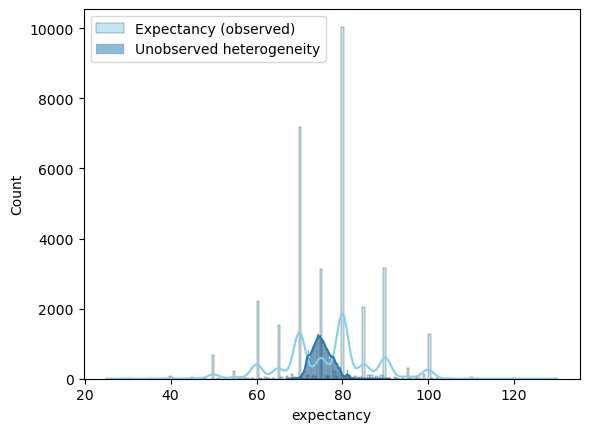

In [41]:
Xpred = X.copy()
Xpred[['edu', 'illness', 'assets', 'tiene_assets','cronica', 'mental', 'cotizando',  'exp_sist', 'year_4', 'year_6', 'year_9', 'year_12']] = 0
Xpred['const']=1
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="Expectancy (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="Unobserved heterogeneity", kde=True)

plt.legend() 
plt.show()

### Respuesta
Vemos que el modelo detecta efectos no observados que están cargados a la izquierda de la media de los datos obsevados, por los que estos deben compensar los efectos que se observaron desde las variables observadas para ajustarse de mejor manera a los datos.

## 8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

### Respuesta
Debido a la coherencia de los coeficientes de los modelos, el que considero que tiene la mayor cantidad de efectos que podrían comprenderse en la vida real, son los del CRE, por lo que me quedo con este modelo, además de medir de manera versátil ambos alcances en simultáneo que tiene el modelo FE y CE, y no está demás recalcar el R2 que posee este.


## 9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.